# Employee Attrition Prediction using XGBoost

### End-to-End Machine Learning Classification Project

## Project Overview

The objective of this project is to predict employee attrition using XGBoost. The project demonstrates an end-to-end machine learning workflow including data preprocessing, exploratory data analysis, feature engineering, model building, hyperparameter tuning using GridSearchCV, model evaluation, and feature importance analysis.

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)
from sklearn.model_selection import GridSearchCV

 Load Dataset

In [2]:
df = pd.read_csv('../data/employee_attrition.csv')

In [ ]:
df.head()


Exploratory Data Analysis

In [ ]:
df.columns

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

In [ ]:
df["Attrition"].value_counts(normalize=True)

In [ ]:

df["Attrition"].value_counts().plot(kind="bar")

plt.title("Employee Attrition")

plt.xlabel("Attrition")

plt.ylabel("Count")

plt.show()

Univariate Analysis

In [ ]:
df["Age"].describe()

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=15)

plt.title("Distribution of Employee Age")

plt.xlabel("Age")

plt.ylabel("Number of Employees")

plt.show()

In [ ]:
plt.figure(figsize=(8,2))

plt.boxplot(df["Age"], vert=False)

plt.title("Age Boxplot")

plt.show()

Bivariate Analysis

In [ ]:
pd.crosstab(df["OverTime"], df["Attrition"])

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="OverTime", hue="Attrition")

plt.title("Attrition by Overtime")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="Age"
)

plt.title("Age vs Attrition")

plt.show()

In [ ]:
sns.countplot(data=df, x="WorkLifeBalance", hue="Attrition")
plt.show()

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

Feature Selection

In [3]:
df = df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "StandardHours",
        "Over18"
    ]
)

In [ ]:
df.columns

Missing value handling

In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

In [4]:
#Stop execution if there are any missing values
assert df.isnull().sum().sum() == 0

Seperating feature and target

In [5]:
# 1. Create X and y
X = df.drop("Attrition", axis=1)

y = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

#Remember: axis=0 refers to rows, axis=1 refers to columns

In [93]:
print(y.unique())

[1 0]


Train test split

In [6]:
# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [95]:
print("Original distribution:")
print(y.value_counts(normalize=True))

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Original distribution:
Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64

Training distribution:
Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Testing distribution:
Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


In [7]:
# 3. Identify column types FROM X_train
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

categorical_cols = X_train.select_dtypes(include=["object"]).columns

print("Numerical Columns:")
print(numerical_cols)

print()

print("Categorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')

Categorical Columns:
Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='str')


C:\Users\AyushiMakwana\AppData\Local\Temp\ipykernel_13036\3044318413.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object"]).columns


Categorical encoding

In [8]:
# 4. Create encoder
categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [9]:
# 5. Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_encoder, categorical_cols)
    ],
    remainder="passthrough"
)

Build Pipeline

In [10]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

 Hyperparameter Tuning

In [11]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.2]
}

In [12]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

In [ ]:
# pipeline.fit(X_train, y_train) Train Baseline Model

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.1, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_example

In [14]:
print(grid_search.best_params_)

{'model__learning_rate': 0.2, 'model__max_depth': 5, 'model__n_estimators': 300}


In [15]:
print(grid_search.best_score_)

0.7943853442250449


In [16]:
best_model = grid_search.best_estimator_

In [17]:
y_pred = best_model.predict(X_test)
print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 1]


In [18]:
accuracy_score(y_test, y_pred)

0.8639455782312925

Model Evaluation

In [19]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[242   5]
 [ 35  12]]


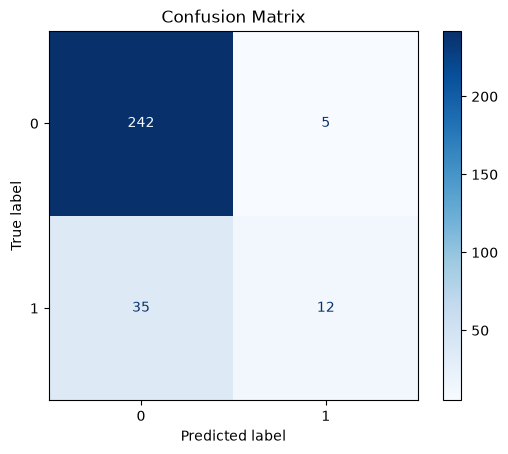

In [20]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.71      0.26      0.38        47

    accuracy                           0.86       294
   macro avg       0.79      0.62      0.65       294
weighted avg       0.85      0.86      0.84       294



Probability Prediction

In [22]:
#y_prob = pipeline.predict_proba(X_test)

# probability of leaving
y_prob = best_model.predict_proba(X_test)[:, 1]

In [23]:
print(y_prob[:5])

[6.6036530e-02 3.1671277e-04 6.2546651e-03 9.9463468e-06 3.3480428e-02]


In [24]:
auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {auc:.3f}")

ROC-AUC Score: 0.780


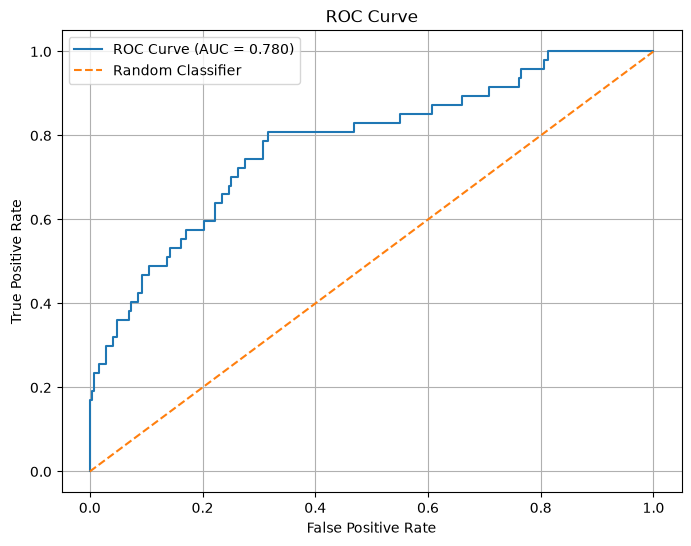

In [25]:
# ROC curve

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

Feature Importance

In [26]:
xgb_model = best_model.named_steps["model"]

In [28]:
feature_importance = xgb_model.feature_importances_
print(feature_importance)

[0.02981486 0.023159   0.01637411 0.         0.01736463 0.01176749
 0.         0.00824122 0.01328366 0.01059267 0.01334234 0.02549394
 0.01173124 0.         0.04741735 0.         0.01720711 0.
 0.02038665 0.06324781 0.03634006 0.05098669 0.02053248 0.03233762
 0.00516722 0.01895124 0.03777096 0.         0.02363872 0.01708511
 0.01620379 0.01455142 0.0231288  0.01038538 0.03194501 0.03396095
 0.02021421 0.02117136 0.01129044 0.02771788 0.01233052 0.
 0.0185088  0.03442813 0.04428806 0.01427243 0.02150296 0.01372414
 0.01971196 0.01505061 0.02337886]


retrieve the feature names

In [29]:
preprocessor = best_model.named_steps["preprocessor"]

In [30]:
feature_names = preprocessor.get_feature_names_out()

In [31]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

In [32]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [33]:
importance_df.head(10)

,Feature,Importance
19,categorical__JobRole_Research Director,0.063248
21,categorical__JobRole_Sales Executive,0.050987
14,categorical__JobRole_Healthcare Representative,0.047417
44,remainder__TotalWorkingYears,0.044288
26,categorical__OverTime_No,0.037771
20,categorical__JobRole_Research Scientist,0.036340
43,remainder__StockOptionLevel,0.034428
35,remainder__JobLevel,0.033961
23,categorical__MaritalStatus_Divorced,0.032338
34,remainder__JobInvolvement,0.031945


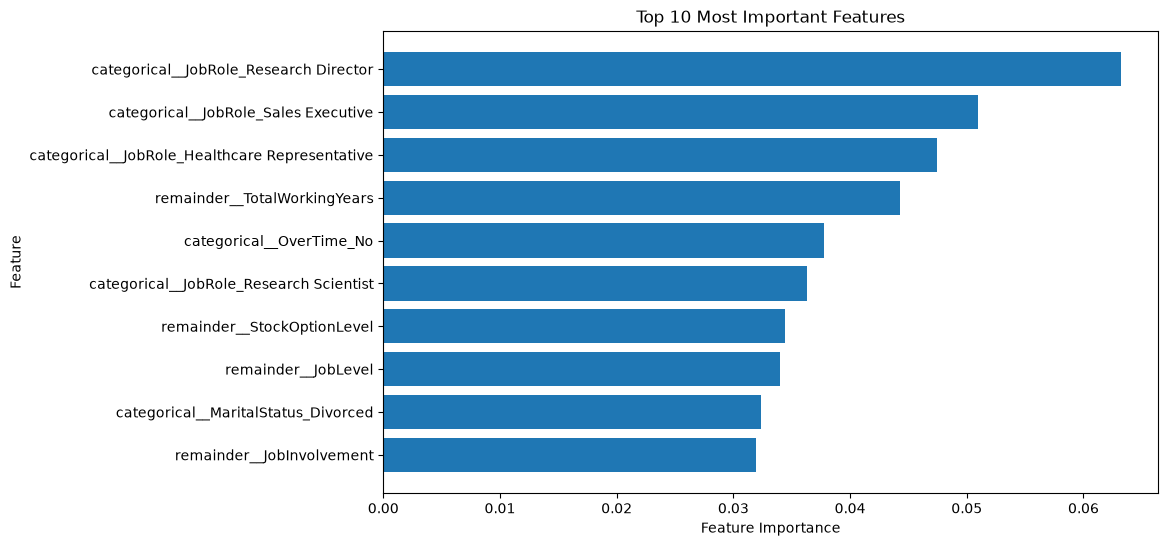

In [34]:
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.show()